In [1]:
import corner
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import ocnus_py
from ocnus_py import COREModel, COREMagFilter, Obs, Univariate, ObsVecNoise

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.INFO)

In [ ]:
# Set up model priors
model = COREModel([
    Univariate.uniform("rot_z", -1.0, 1.0),
    Univariate.uniform("rot_y", -0.25, 0.25),
    Univariate.uniform("rot_x", -3.5, 3.14),
    Univariate.constant("r_0rs", 20.0),
    Univariate.uniform("d_1au", 0.05, 0.35),
    Univariate.uniform("cs_delta", 0.5, 1.0),
    Univariate.uniform("speed", 700.0, 1500.0),
    Univariate.uniform("b_scale", 10.0, 30.0),
    Univariate.uniform("tau", -50.0, 0.0),
    Univariate.constant("sw_speed", 400.0),
    Univariate.constant("sw_gamma", 1.0),
])

ref_data = np.array([
    [-3.13531505, -13.98423491, -6.64658269],
    [-3.38360946, -15.34720671, -1.71139834],
    [-4.21540068, -13.93568105, 4.73878965],
    [-5.41469694, -13.9772912, 4.14112123],
    [-4.30711573, -12.61217154, 5.78382821],
])

# set up observation
obs = Obs(
    [3.5 * 24.0 * 3600.0 + 2.0 * 3600.0 * i for i in range(len(ref_data))],
    np.array([[1.0, 0.0, 0.0] for _ in range(len(ref_data))]),
)


filter = model.new_mag_filter(obs, ref_data, 2048, 42)
filter.initialize(metric='nchisq', threshold=1.0)

particles_init = filter.particles()

In [3]:
filter_abc = filter.copy()

noise = ObsVecNoise.additive_normal(std_dev=1.0)

for threshold in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.25]:
    ess = filter_abc.abc_mvnk(metric='nchisq', threshold=threshold, noise=noise)
    print("Filtering with threshold {}, effective sample size: {:.1f}".format(threshold, ess))

print("ABC Mean: {:.3f}".format(np.mean(filter_abc.errors())))
print("ABC Minimum: {:.3f}".format(np.min(filter_abc.errors())))

particles_abc = filter_abc.particles()

Filtering with threshold 0.9, effective sample size: 1367.2
Filtering with threshold 0.8, effective sample size: 1454.8
Filtering with threshold 0.7, effective sample size: 1315.3
Filtering with threshold 0.6, effective sample size: 1398.6
Filtering with threshold 0.5, effective sample size: 1462.4
Filtering with threshold 0.4, effective sample size: 1289.9
Filtering with threshold 0.3, effective sample size: 1288.3
Filtering with threshold 0.25, effective sample size: 1272.9
ABC Mean: 0.163
ABC Minimum: 0.029


In [4]:
filter_dev = filter.copy()

mutation_counter = 0

for i in range(400):
    mutation_counter += filter_dev.dev(metric='nchisq', mutation_factor=0.1, recombination_factor=0.8)

    if i > 0 and i % 50 == 0:
        print("Last 40 iterations: {} mutations".format(mutation_counter))
        mutation_counter = 0

print("DEV Minimum: {:.3f}".format(np.min(filter_dev.errors())))

particles_dev = filter_dev.particles()

dev_min = particles_dev[0][np.argmin(filter_dev.errors())]


Last 40 iterations: 35696 mutations
Last 40 iterations: 31616 mutations
Last 40 iterations: 22912 mutations
Last 40 iterations: 21111 mutations
Last 40 iterations: 19546 mutations
Last 40 iterations: 14467 mutations
Last 40 iterations: 15772 mutations
DEV Minimum: 0.016


In [ ]:
autorange = np.array([np.min(particles_init[0], axis=0), np.max(particles_init[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(8, 8))
corner.corner(particles_init[0].T[autoflag].T, 
              weights=np.ones_like(particles_abc[1]) / 2048, color='k',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2)
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_dev[0].T[autoflag].T, 
              weights=np.ones_like(particles_abc[1]) / 2048, color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='g', edgecolor='k', label="Differential Evolution (DEV)"),
], loc='upper right')
plt.show()

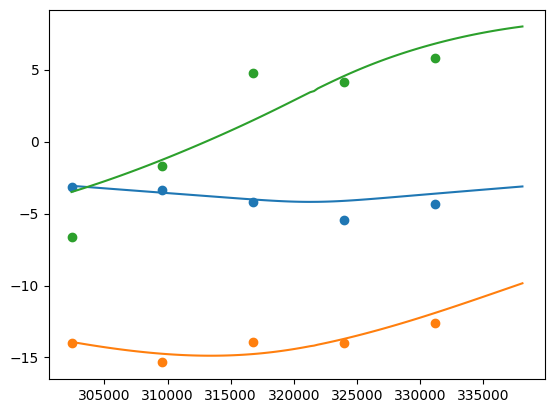

In [21]:
# set up observation
Nfac = 24

obs_full = Obs(
    [3.5 * 24.0 * 3600.0 + 2.0 * 3600.0 * i / Nfac for i in range(Nfac * len(ref_data))],
    np.array([[1.0, 0.0, 0.0] for _ in range(Nfac * len(ref_data))]),
)

reconstr = filter.simulate(obs_full).get(np.argmin(filter.errors()))

plt.figure()
plt.plot(obs_full.timestamps(), reconstr[:, 0])
plt.plot(obs_full.timestamps(), reconstr[:, 1])
plt.plot(obs_full.timestamps(), reconstr[:, 2])

plt.scatter(obs.timestamps(), ref_data[:, 0])
plt.scatter(obs.timestamps(), ref_data[:, 1])
plt.scatter(obs.timestamps(), ref_data[:, 2])

np.float64(0.022222811034143267)